In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cbc information.xlsx to cbc information (1).xlsx


In [ ]:
data = pd.read_excel("cbc information.xlsx")   # or read_csv

In [ ]:
print(data.head())
print(data.columns)
print(data.info())

   ID   WBC  LYMp  MIDp  NEUTp  LYMn  MIDn  NEUTn   RBC  HGB  ...   MCV   MCH  \
0   1  10.0  43.2   6.7   50.1   4.3   0.7    5.0  2.77  7.3  ...  87.7  26.3   
1   2  10.0  42.4   5.3   52.3   4.2   0.5    5.3  2.84  7.3  ...  88.2  25.7   
2   3   7.2  30.7   8.6   60.7   2.2   0.6    4.4  3.97  9.0  ...  77.0  22.6   
3   4   6.0  30.2   6.3   63.5   1.8   0.4    3.8  4.22  3.8  ...  77.9  23.2   
4   5   4.2  39.1   7.2   53.7   1.6   0.3    2.3  3.93  0.4  ...  80.6  23.9   

   MCHC  RDWSD  RDWCV    PLT   MPV   PDW   PCT  PLCR  
0  30.1   35.3   11.4  189.0   9.2  12.5  0.17  22.3  
1  20.2   35.3   11.4  180.0   8.9  12.5  0.16  19.5  
2  29.5   37.2   13.7  148.0  10.1  14.3  0.14  30.5  
3  29.8   46.5   17.0  143.0   8.6  11.3  0.12  16.4  
4  29.7   42.7   15.1  236.0  19.5  12.8  0.22  24.8  

[5 rows x 21 columns]
Index(['ID', 'WBC', 'LYMp', 'MIDp', 'NEUTp', 'LYMn', 'MIDn', 'NEUTn', 'RBC',
       'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDWSD', 'RDWCV', 'PLT', 'MPV',
       '

DATA cleaning process


In [ ]:
data = data.drop(columns=["ID"], errors='ignore')

In [ ]:
data = data.fillna(data.mean())

In [ ]:
print(data.columns)

Index(['WBC', 'LYMp', 'MIDp', 'NEUTp', 'LYMn', 'MIDn', 'NEUTn', 'RBC', 'HGB',
       'HCT', 'MCV', 'MCH', 'MCHC', 'RDWSD', 'RDWCV', 'PLT', 'MPV', 'PDW',
       'PCT', 'PLCR'],
      dtype='object')


In [ ]:
data["Diagnosis"] = (
    (data["WBC"] > 11) |
    (data["LYMp"] > 40) |
    (data["PLT"] < 150)
).astype(int)

In [ ]:
X = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]

In [ ]:
data["Diagnosis"] = data["Diagnosis"].map({"Normal":0, "Cancer":1})

EDA

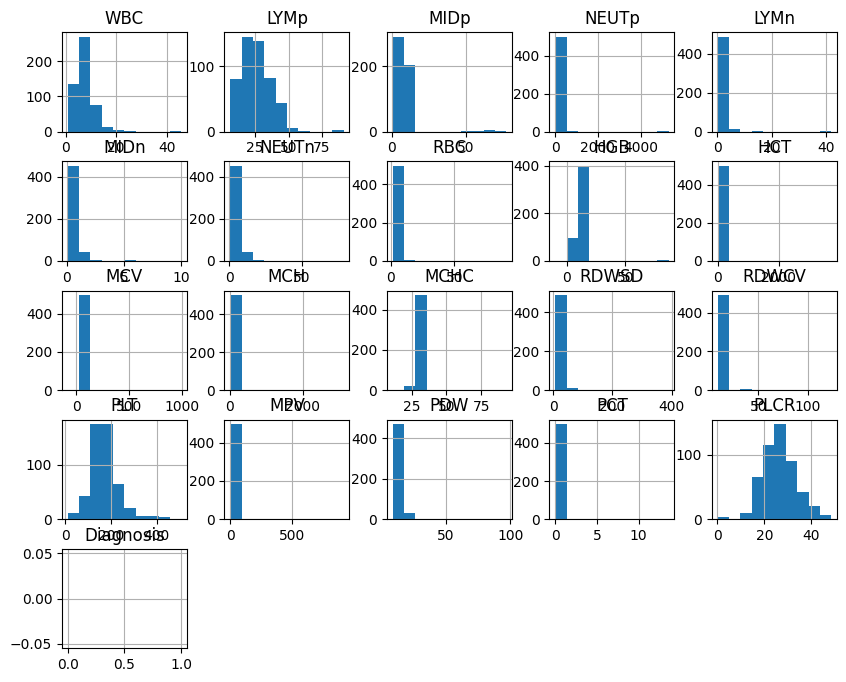

In [ ]:
data.hist(figsize=(10,8))
plt.show()

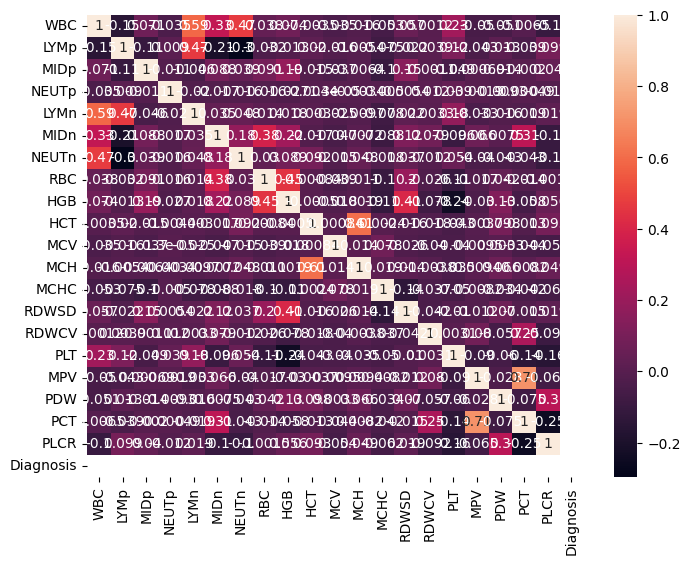

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.show()

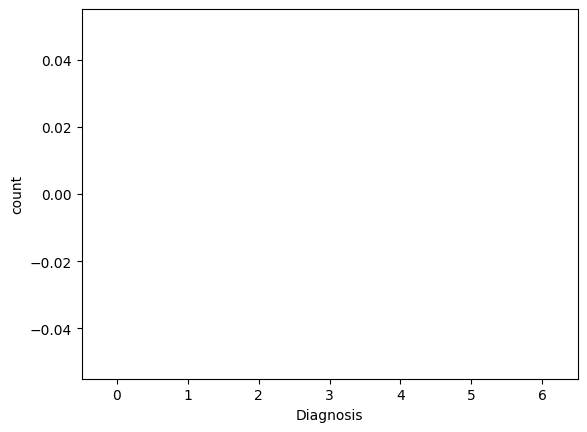

In [ ]:
sns.countplot(x='Diagnosis', data=data)
plt.show()

Feature Scaling & Target Split

In [ ]:
X = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Training Models

In [ ]:
print(data.columns)

Index(['WBC', 'LYMp', 'MIDp', 'NEUTp', 'LYMn', 'MIDn', 'NEUTn', 'RBC', 'HGB',
       'HCT', 'MCV', 'MCH', 'MCHC', 'RDWSD', 'RDWCV', 'PLT', 'MPV', 'PDW',
       'PCT', 'PLCR', 'Diagnosis'],
      dtype='object')


In [ ]:
data = data.apply(pd.to_numeric, errors='coerce')

In [ ]:
data["Diagnosis"] = (
    (data["WBC"] > 11).astype(int) +
    (data["LYMp"] > 40).astype(int) +
    (data["PLT"] < 150).astype(int)
)

data["Diagnosis"] = (data["Diagnosis"] >= 1).astype(int)

In [ ]:
print(data["Diagnosis"].value_counts())
print(data.isnull().sum())

Diagnosis
1    256
0    244
Name: count, dtype: int64
WBC          0
LYMp         0
MIDp         0
NEUTp        0
LYMn         0
MIDn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
RDWSD        0
RDWCV        0
PLT          0
MPV          0
PDW          0
PCT          0
PLCR         0
Diagnosis    0
dtype: int64


Logistic Regresion

In [ ]:
print("NaN in y:", y.isnull().sum())
print("NaN in X:", np.isnan(X_scaled).sum())

NaN in y: 500
NaN in X: 0


In [ ]:
print(data["Diagnosis"].value_counts())

Diagnosis
1    256
0    244
Name: count, dtype: int64


In [ ]:
data = data.apply(pd.to_numeric, errors='coerce')

In [ ]:
data = data.fillna(data.mean())

In [ ]:
data["Diagnosis"] = 0

data.loc[data["WBC"] > 11, "Diagnosis"] = 1
data.loc[data["LYMp"] > 40, "Diagnosis"] = 1
data.loc[data["PLT"] < 150, "Diagnosis"] = 1

In [ ]:
print(data["Diagnosis"].value_counts())

Diagnosis
1    256
0    244
Name: count, dtype: int64


In [ ]:
print("NaN in Diagnosis:", data["Diagnosis"].isnull().sum())

NaN in Diagnosis: 0


In [ ]:
import pandas as pd
import numpy as np

# Convert everything to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Fill missing values
data = data.fillna(data.mean())

In [ ]:
data["Diagnosis"] = 0

data.loc[data["WBC"] > 11, "Diagnosis"] = 1
data.loc[data["LYMp"] > 40, "Diagnosis"] = 1
data.loc[data["PLT"] < 150, "Diagnosis"] = 1

In [ ]:
data = data.dropna()

In [ ]:
X = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]

In [ ]:
print("NaN in y:", y.isnull().sum())
print("NaN in X:", X.isnull().sum().sum())

NaN in y: 0
NaN in X: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("NaN in y_train:", y_train.isnull().sum())

NaN in y_train: 400


In [ ]:
print("NaN in y_train:", y_train.isnull().sum())

NaN in y_train: 400


In [ ]:
# STEP 1: Convert to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# STEP 2: Fill missing values FIRST
data = data.fillna(data.mean())

# STEP 3: Create Diagnosis safely
data["Diagnosis"] = 0

data.loc[data["WBC"] > 11, "Diagnosis"] = 1
data.loc[data["LYMp"] > 40, "Diagnosis"] = 1
data.loc[data["PLT"] < 150, "Diagnosis"] = 1

# STEP 4: IMPORTANT — DROP AGAIN (extra safety)
data = data.dropna()

# STEP 5: RECREATE X and y (VERY IMPORTANT)
X = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]

# STEP 6: VERIFY (THIS MUST BE ZERO)
print("NaN in y:", y.isnull().sum())
print("Unique values in y:", y.unique())

NaN in y: 0
Unique values in y: [1 0]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("NaN in y_train:", y_train.isnull().sum())

NaN in y_train: 0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

logistic regresion

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

models = {
    "LR": lr,
    "DT": dt,
    "SVM": svm,
    "RF": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

LR Accuracy: 0.72
DT Accuracy: 1.0
SVM Accuracy: 0.91
RF Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[54  0]
 [ 0 46]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        46

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
X = data.drop(["Diagnosis", "WBC", "LYMp", "PLT"], axis=1)

In [ ]:
from sklearn.metrics import accuracy_score

models = {
    "LR": lr,
    "DT": dt,
    "SVM": svm,
    "RF": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

LR Accuracy: 0.72
DT Accuracy: 1.0
SVM Accuracy: 0.91
RF Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[54  0]
 [ 0 46]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        46

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
X = data.drop([
    "Diagnosis",
    "WBC",
    "LYMp",
    "PLT",
    "LYMn",
    "NEUTp",
    "NEUTn",
    "MIDp",
    "MIDn"
], axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.87


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_scaled, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.8160000000000001


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[48  6]
 [ 7 39]]
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        54
           1       0.87      0.85      0.86        46

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



In [ ]:
importance = rf.feature_importances_

for i, v in enumerate(importance):
    print(X.columns[i], ":", v)

RBC : 0.08760172513834213
HGB : 0.06547465799024285
HCT : 0.06929425589684202
MCV : 0.07379913382225715
MCH : 0.057766611907388674
MCHC : 0.0586378285132756
RDWSD : 0.029046346128109045
RDWCV : 0.0507735491009957
MPV : 0.06500800184542321
PDW : 0.05190713204323342
PCT : 0.31961535025308296
PLCR : 0.07107540736080714
